# Visualization & Dashboard

**Continuing from:** `feature_engineering_analysis.ipynb` — that notebook turned the clean Superstore data into a set of analysis-ready tables and answered the five business questions in text/table form. This notebook's job is purely presentational: turn those already-computed tables into charts, without recomputing any aggregation logic.

> **Note on notebooks and kernels:** this notebook does **not** share memory with `feature_engineering_analysis.ipynb` — each `.ipynb` file runs its own kernel. Step 0 below loads the tables that notebook exported to `handoff_data/`, rather than assuming they already exist in memory.

### Step 0 — Setup & Recap

Load every table named in the feature-engineering notebook's `handoff_manifest`, straight back from `handoff_data/`. Nothing is recomputed here — this is a read-only reload of work already done.

In [42]:
# Importing the proper and required data + visualization packages
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import plotly.express as px

In [43]:
# Row-level / per-entity tables
df_clean = pd.read_parquet("handoff_data/df_clean.parquet", engine="pyarrow")
customer_features = pd.read_parquet("handoff_data/customer_features.parquet", engine="pyarrow")
product_features = pd.read_parquet("handoff_data/product_features.parquet", engine="pyarrow")
rfm = pd.read_parquet("handoff_data/rfm.parquet", engine="pyarrow")

In [44]:
df_clean["Discount Bucket"]

0           No Discount
1           No Discount
2           No Discount
3       Meduim Discount
4          Low Discount
             ...       
9988       Low Discount
9989        No Discount
9990       Low Discount
9991        No Discount
9992        No Discount
Name: Discount Bucket, Length: 9993, dtype: category
Categories (5, str): ['No Discount' < 'Low Discount' < 'Meduim Discount' < 'High Discount' < 'Extreme Discount']

In [45]:
# Using the index_col parameter will ensure that we have the x-label set as an index to the chart
# So, we are going to set any other stuff, it will work directly in the plotting phase!
# The difference between adding the .squeeze('columns) is that, using this option we are going to convert the one
# column dataframe into a labeld series which will help plotting the data easily!
state_profit = pd.read_csv("handoff_data/state_profit.csv", index_col="State")
# keep_default_na=False: the "None" discount bucket is a literal label, not a
# missing value -- pandas' default NA-string list would otherwise silently
# turn that row's index into NaN on reload.
discount_profit = pd.read_csv("handoff_data/discount_profit.csv", index_col="Discount Bucket", keep_default_na=False).squeeze("columns")

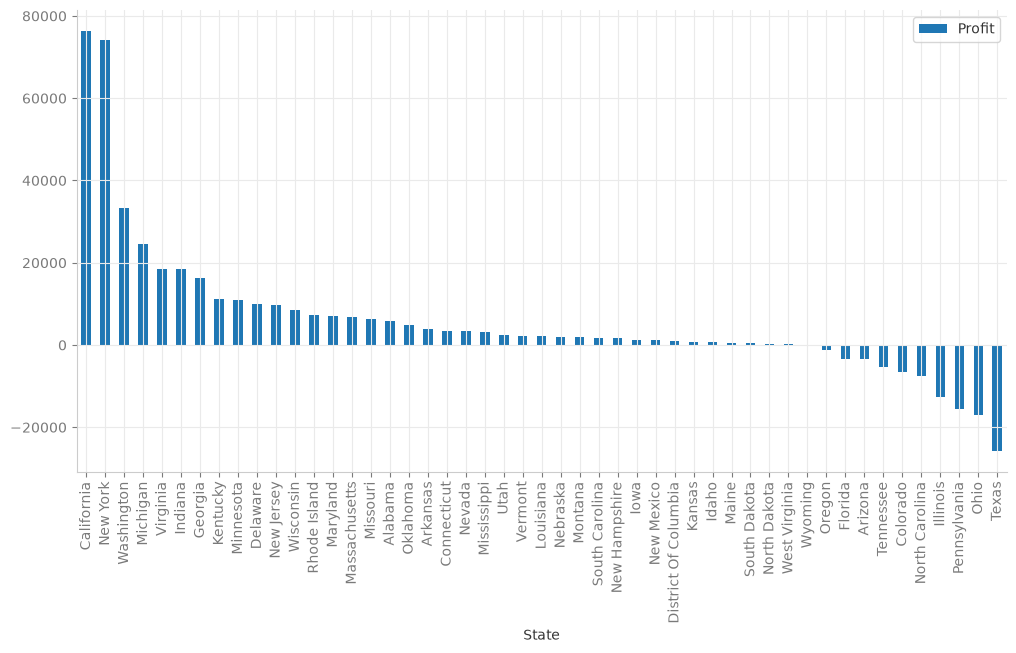

In [49]:
state_profit.plot(kind='bar', figsize=(12,6))
plt.show()

In [50]:
ship_mode_summary = pd.read_csv("handoff_data/ship_mode_summary.csv", index_col="Ship Mode")
region_summary = pd.read_csv("handoff_data/region_summary.csv", index_col="Region")
category_summary = pd.read_csv("handoff_data/category_summary.csv", index_col="Category")
pivot = pd.read_csv("handoff_data/pivot_region_category.csv", index_col="Region")

### Step 1 — Telling a Story, Not Just Five Charts

Rather than five disconnected charts in question order, the dashboard is sequenced as a chain of *why*: each panel sets up the question the next one answers.

**Where are we winning/losing → why → does operations explain it → when does it happen → who matters most.**

0. **KPI strip** — orientation: the five headline numbers before drilling into anything.
1. **Profit by State** (Q1) — surfaces *that* some states lose money.
2. **Discount vs. Profit** (Q2) — answers *why*: the Step 7 synthesis already flags discounting as the likely driver of state-level losses.
3. **Ship Mode** (Q3) — rules out an alternative explanation (operations); profit is flat regardless of shipping choice.
4. **Seasonality** (Q4) — shifts from *why* to *when* demand spikes.
5. **Customer Value / RFM** (Q5) — closes on *who* — spend is concentrated in a few accounts.
6. **Takeaways** — closes the dashboard with stated conclusions, not just the last chart.

Panels 1 and 2 intentionally share the same diverging red/green color scale (loss/profit) since they're presented as cause-and-effect. Panel 1 ships two versions of the same chart on purpose — a static matplotlib bar and an interactive Plotly choropleth — to show two valid ways of visualizing the same geographic data.

In [51]:
# Shared palette: diverging (profit/loss), categorical (fixed order), accent
COLOR_POS = "#2E7D32"      # profit / gain
COLOR_NEG = "#C62828"      # loss
CATEGORICAL = ["#4C72B0", "#DD8452", "#55A868", "#8172B2"]
ACCENT = CATEGORICAL[1]    # used to call out weekends / peak months
INK = "#333333"
MUTED = "#7A7A7A"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#CCCCCC",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": "#EAEAEA",
    "grid.linewidth": 0.8,
    "font.size": 10,
    "figure.facecolor": "white",
})

# USPS abbreviations -- needed for the Plotly choropleth (locationmode="USA-states"
# only accepts codes, not full names)
STATE_ABBREV = {
    "Alabama": "AL", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District Of Columbia": "DC", "Florida": "FL", "Georgia": "GA",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY",
}

### Panel 0 — KPI Strip

Five headline numbers, computed directly from `df_clean` -- pure orientation before the story starts.

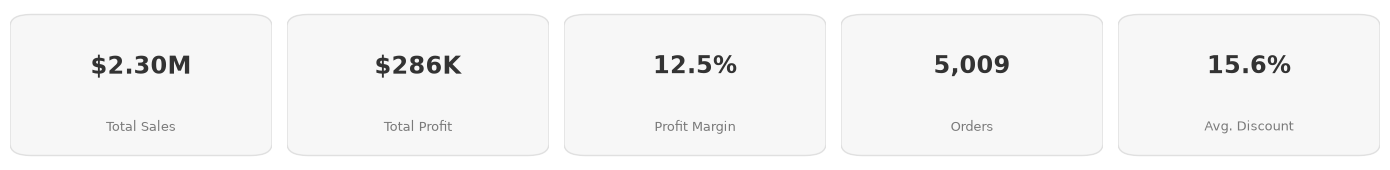

In [52]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
overall_margin = total_profit / total_sales * 100
total_orders = df_clean["Order ID"].nunique()
avg_discount = df_clean["Discount"].mean() * 100

kpis = [
    ("Total Sales", f"${total_sales/1e6:.2f}M"),
    ("Total Profit", f"${total_profit/1e3:.0f}K"),
    ("Profit Margin", f"{overall_margin:.1f}%"),
    ("Orders", f"{total_orders:,}"),
    ("Avg. Discount", f"{avg_discount:.1f}%"),
]

fig, axes = plt.subplots(1, 5, figsize=(14, 1.8))
for ax, (label, value) in zip(axes, kpis):
    ax.axis("off")
    ax.add_patch(FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.9, boxstyle="round,pad=0.02,rounding_size=0.08",
        transform=ax.transAxes, facecolor="#F7F7F7", edgecolor="#E0E0E0", linewidth=1,
    ))
    ax.text(0.5, 0.62, value, transform=ax.transAxes, ha="center", va="center",
            fontsize=17, fontweight="bold", color=INK)
    ax.text(0.5, 0.22, label, transform=ax.transAxes, ha="center", va="center",
            fontsize=9.5, color=MUTED)
plt.tight_layout()
plt.show()

### Panel 1 — Profit by State (Q1)

Which state generates the most profit, and which the biggest loss? Two versions of the same chart, on purpose: a static matplotlib bar (top 10 / bottom 10, easy to scan) and an interactive Plotly choropleth (every state at once, hover for the exact figure). Same data (`state_profit`), same diverging red/green scale, two different tools -- a deliberate side-by-side for comparing what each is good at.

In [59]:
# 1b. Interactive Plotly version: every state at once, hover for the exact figure
sp_df = state_profit.reset_index()
sp_df.columns = ["State", "Profit"]
sp_df["Code"] = sp_df["State"].map(STATE_ABBREV)

fig_map = px.choropleth(
    sp_df,
    locations="Code",
    locationmode="USA-states",
    color="Profit",
    scope="usa",
    color_continuous_scale=[COLOR_NEG, "#F5F5F5", COLOR_POS],
    color_continuous_midpoint=0,
    hover_name="State",
    hover_data={"Code": False, "Profit": ":$,.0f"},
    title="Total Profit by State",
)
fig_map.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig_map.show()

### Panel 2 — Discount vs. Profit (Q2)

Follows straight from Panel 1's open question: is discounting what's driving state-level losses? Same diverging red/green scale as Panel 1, so the color continues to mean the same thing.

In [62]:
df_clean["Discount Bucket"]

0           No Discount
1           No Discount
2           No Discount
3       Meduim Discount
4          Low Discount
             ...       
9988       Low Discount
9989        No Discount
9990       Low Discount
9991        No Discount
9992        No Discount
Name: Discount Bucket, Length: 9993, dtype: category
Categories (5, str): ['No Discount' < 'Low Discount' < 'Meduim Discount' < 'High Discount' < 'Extreme Discount']

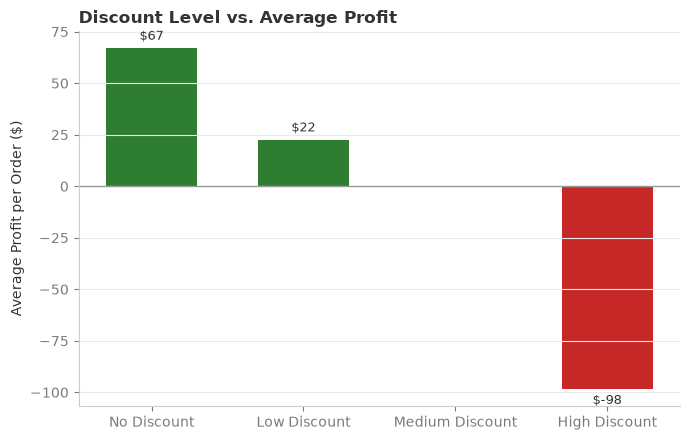

In [63]:
discount_order = ["No Discount", "Low Discount", "Medium Discount", "High Discount", "Very High Discount"]
dp = discount_profit.reindex(discount_order)
colors = [COLOR_POS if v >= 0 else COLOR_NEG for v in dp.values]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(dp.index, dp.values, color=colors, width=0.6)
ax.axhline(0, color="#999999", linewidth=1)
ax.set_ylabel("Average Profit per Order ($)")
ax.set_title("Discount Level vs. Average Profit", loc="left", fontsize=12, fontweight="bold")
for bar, v in zip(bars, dp.values):
    if pd.isna(v):
        continue
    va = "bottom" if v >= 0 else "top"
    ax.annotate(f"${v:,.0f}", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 4 if v >= 0 else -4), textcoords="offset points",
                ha="center", va=va, fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

### Panel 3 — Ship Mode: Profit vs. Shipping Time (Q3)

Rules out an alternative explanation for the state-level losses: is it an operations/shipping problem instead? Two measures on different scales (`$` and days) means two small-multiple bar charts sharing one categorical axis and one fixed color per ship mode -- never a dual-axis chart on a single plot.

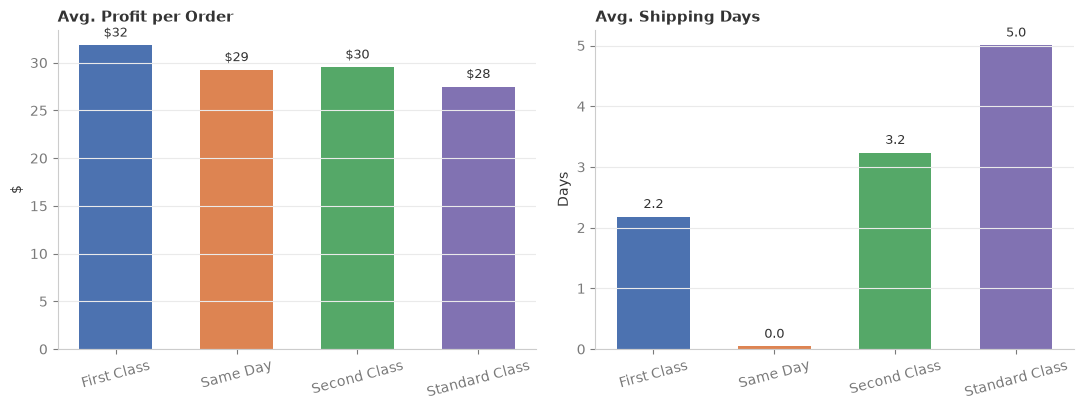

In [64]:
modes = ship_mode_summary.index.tolist()
mode_colors = CATEGORICAL[: len(modes)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
bars = ax.bar(modes, ship_mode_summary["avg_profit"], color=mode_colors, width=0.6)
ax.set_title("Avg. Profit per Order", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("$")
for bar, v in zip(bars, ship_mode_summary["avg_profit"]):
    ax.annotate(f"${v:.0f}", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9)
ax.grid(axis="x", visible=False)

ax = axes[1]
bars = ax.bar(modes, ship_mode_summary["avg_shipping_days"], color=mode_colors, width=0.6)
ax.set_title("Avg. Shipping Days", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("Days")
for bar, v in zip(bars, ship_mode_summary["avg_shipping_days"]):
    ax.annotate(f"{v:.1f}", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontsize=9)
ax.grid(axis="x", visible=False)

for a in axes:
    a.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### Panel 4 — Seasonality in Sales (Q4)

Shifts the story from *why* to *when*: when does demand spike, so the business can staff and stock for it. Monthly trend (line) on the left, weekday pattern (ordered bar, weekend called out) on the right -- both computed directly from `df_clean`, matching Step 6 Q4 in the feature-engineering notebook.

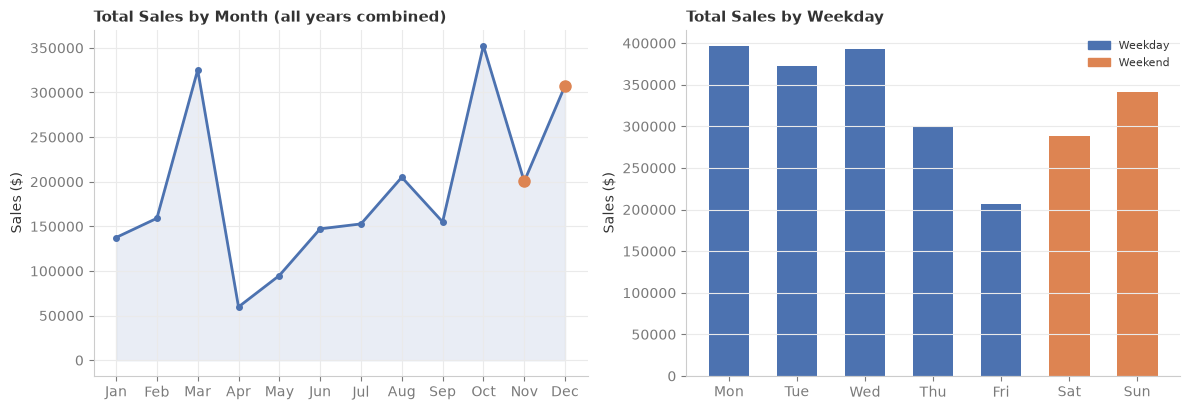

In [65]:
month_sales = df_clean.groupby("Order Month", observed=True)["Sales"].sum().sort_index()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales = df_clean.groupby("Order Weekday", observed=True)["Sales"].sum().reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.plot(month_labels, month_sales.values, color=CATEGORICAL[0], linewidth=2, marker="o", markersize=4)
ax.fill_between(month_labels, month_sales.values, color=CATEGORICAL[0], alpha=0.12)
for i in (10, 11):  # Nov, Dec -- the year-end peak
    ax.plot(month_labels[i], month_sales.values[i], "o", color=ACCENT, markersize=8, zorder=5)
ax.set_title("Total Sales by Month (all years combined)", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("Sales ($)")

ax = axes[1]
bar_colors = [ACCENT if d in ("Saturday", "Sunday") else CATEGORICAL[0] for d in weekday_order]
bars = ax.bar([d[:3] for d in weekday_order], weekday_sales.values, color=bar_colors, width=0.6)
ax.set_title("Total Sales by Weekday", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("Sales ($)")
ax.grid(axis="x", visible=False)
ax.legend(
    handles=[mpatches.Patch(color=CATEGORICAL[0], label="Weekday"),
             mpatches.Patch(color=ACCENT, label="Weekend")],
    frameon=False, fontsize=8, loc="upper right",
)
plt.tight_layout()
plt.show()

### Panel 5 — Customer Value / RFM (Q5)

Closes on *who*: a scatter of Frequency x Monetary, colored by Recency (sequential, single hue -- darker/brighter means more recent), next to a named top-10 list for the concrete answer. `Customer Name` isn't in `rfm` (it's indexed by ID only), so a name lookup is built from `df_clean` -- a label attachment, not a new aggregation.

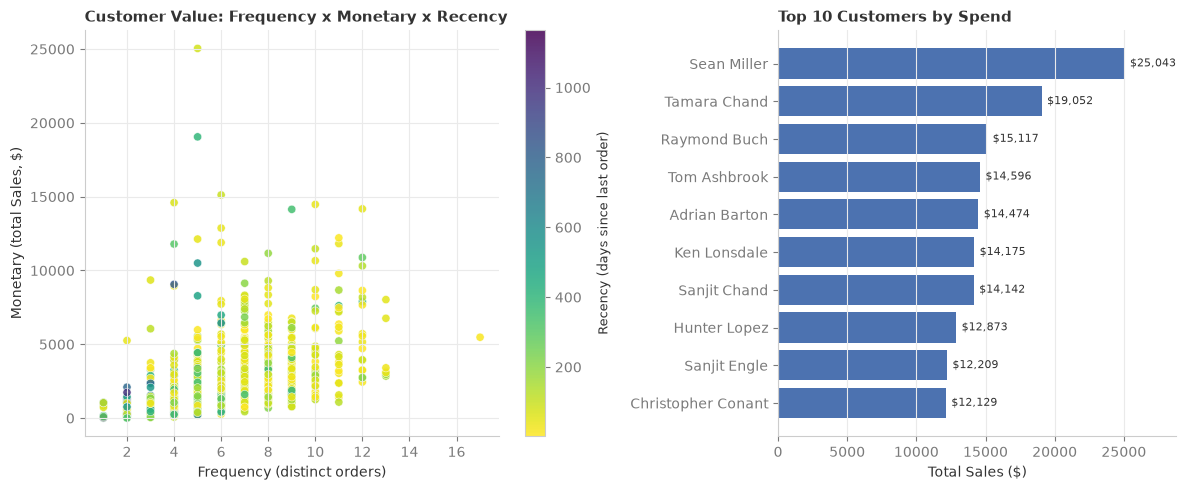

In [66]:
# Name lookup: Customer ID -> Customer Name, a label attachment (not a new aggregation)
name_lookup = df_clean[["Customer ID", "Customer Name"]].drop_duplicates().set_index("Customer ID")["Customer Name"]
rfm_named = rfm.copy()
rfm_named["Customer Name"] = name_lookup.reindex(rfm_named.index)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
sc = ax.scatter(rfm_named["Frequency"], rfm_named["Monetary"], c=rfm_named["Recency"],
                 cmap="viridis_r", s=35, alpha=0.85, edgecolor="white", linewidth=0.4)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Recency (days since last order)", fontsize=9)
ax.set_xlabel("Frequency (distinct orders)")
ax.set_ylabel("Monetary (total Sales, $)")
ax.set_title("Customer Value: Frequency x Monetary x Recency", loc="left", fontsize=11, fontweight="bold")

ax = axes[1]
top10 = rfm_named.sort_values("Monetary", ascending=False).head(10).iloc[::-1]
labels = top10["Customer Name"].fillna(top10.index.to_series())
bars = ax.barh(labels, top10["Monetary"], color=CATEGORICAL[0])
ax.set_title("Top 10 Customers by Spend", loc="left", fontsize=11, fontweight="bold")
ax.set_xlabel("Total Sales ($)")
for bar, v in zip(bars, top10["Monetary"]):
    ax.annotate(f"${v:,.0f}", xy=(v, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=8)
ax.margins(x=0.15)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Panel 6 — Takeaways

Closes the dashboard with stated conclusions instead of just ending on the last chart -- condensed from the feature-engineering notebook's Step 7 insight synthesis.

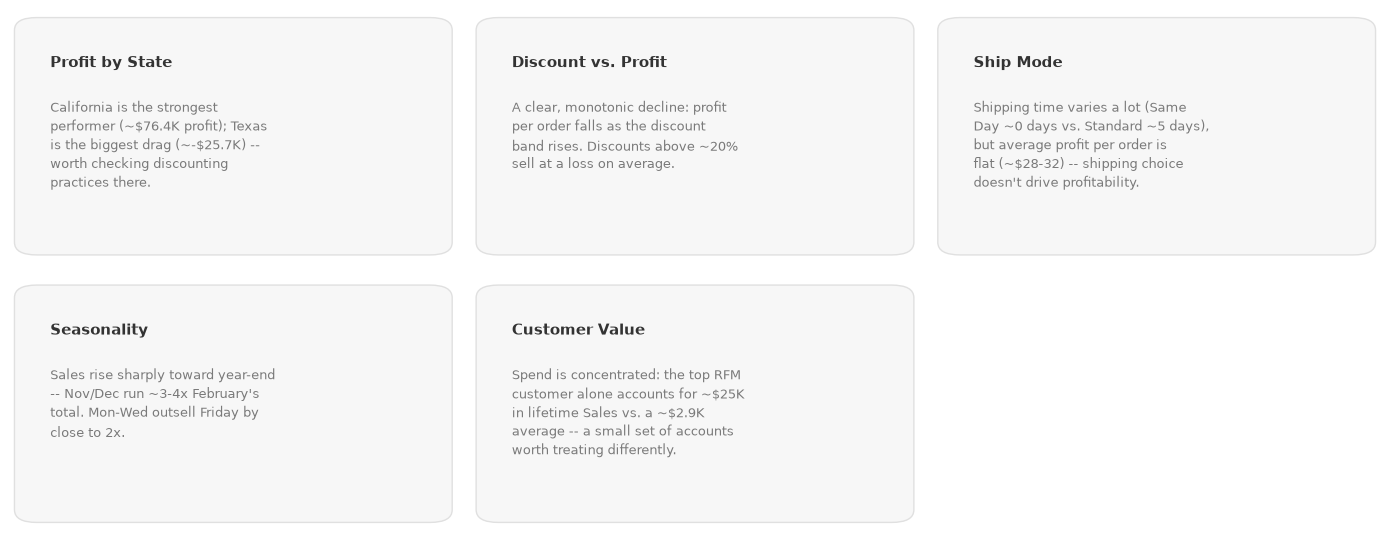

In [67]:
import textwrap

takeaways = [
    ("Profit by State", "California is the strongest performer (~$76.4K profit); Texas is the "
     "biggest drag (~-$25.7K) -- worth checking discounting practices there."),
    ("Discount vs. Profit", "A clear, monotonic decline: profit per order falls as the discount "
     "band rises. Discounts above ~20% sell at a loss on average."),
    ("Ship Mode", "Shipping time varies a lot (Same Day ~0 days vs. Standard ~5 days), but "
     "average profit per order is flat (~$28-32) -- shipping choice doesn't drive profitability."),
    ("Seasonality", "Sales rise sharply toward year-end -- Nov/Dec run ~3-4x February's total. "
     "Mon-Wed outsell Friday by close to 2x."),
    ("Customer Value", "Spend is concentrated: the top RFM customer alone accounts for ~$25K "
     "in lifetime Sales vs. a ~$2.9K average -- a small set of accounts worth treating differently."),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 5.5))
axes = axes.flatten()
for ax, (title, body) in zip(axes, takeaways):
    ax.axis("off")
    ax.add_patch(FancyBboxPatch(
        (0.03, 0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.05",
        transform=ax.transAxes, facecolor="#F7F7F7", edgecolor="#E0E0E0", linewidth=1,
    ))
    ax.text(0.09, 0.82, title, transform=ax.transAxes, ha="left", va="top",
            fontsize=11, fontweight="bold", color=INK)
    wrapped = "\n".join(textwrap.wrap(body, width=34))
    ax.text(0.09, 0.65, wrapped, transform=ax.transAxes, ha="left", va="top",
            fontsize=9, color=MUTED, linespacing=1.5)
axes[-1].axis("off")  # 6th grid cell unused (5 takeaways)
plt.tight_layout()
plt.show()